In [1]:
import librosa as librosa
import scipy
import matplotlib.pyplot as plt
import numpy as np


In [2]:
audio = "music_for_chroma/Avanti-TooManyTimes(freetouse.com).mp3"

#extract the samplingrate and create the waveform of the audio
waveform, sampling_rate = librosa.load(audio, sr=None)

#separate harmonics and percussives into two waveforms
y_harmonic, y_percussive = librosa.effects.hpss(waveform)

jump_time = 0.05 #

hop_length = int(sampling_rate * jump_time)

chroma = librosa.feature.chroma_cqt(y=y_harmonic,sr=sampling_rate, hop_length=hop_length)
print(chroma)

print("Shape: ",chroma.shape)




[[0.32572424 0.08467761 0.03783626 ... 0.36347613 0.3723187  0.38232252]
 [1.         1.         1.         ... 0.36367297 0.38613197 0.35855806]
 [0.20399961 0.03917183 0.02524515 ... 0.3849875  0.39614394 0.37562725]
 ...
 [0.04153638 0.00979238 0.00770862 ... 1.         1.         1.        ]
 [0.07154177 0.01200596 0.00595178 ... 0.40117094 0.38514322 0.40747586]
 [0.15959857 0.03117717 0.02695693 ... 0.5085363  0.50295734 0.510205  ]]
Shape:  (12, 4029)


**Question:**  
What is the difference between chroma_stft and chroma_cqt?  
- chroma_stft -> linear frequency scale
- chroma_cqt -> log/musical frequency scale  

Both will give you a numpy array shape (12,T)  
  
**From Librosas documentation:**  
"chroma_stft performs short-time fourier transform of an audio input and maps each STFT bin to chroma, while chroma_cqt uses constant-Q transform and maps each cq-bin to chroma."


[Text(0, 0.5, 'CQT')]

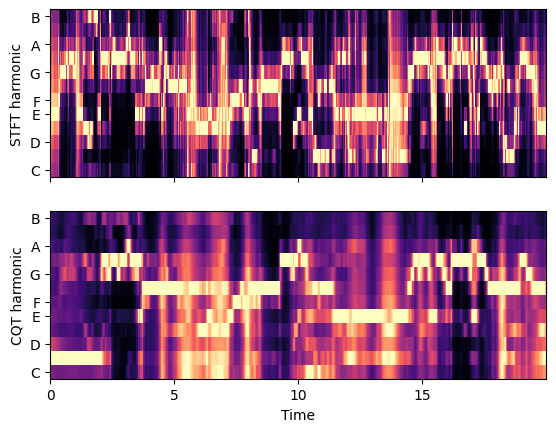

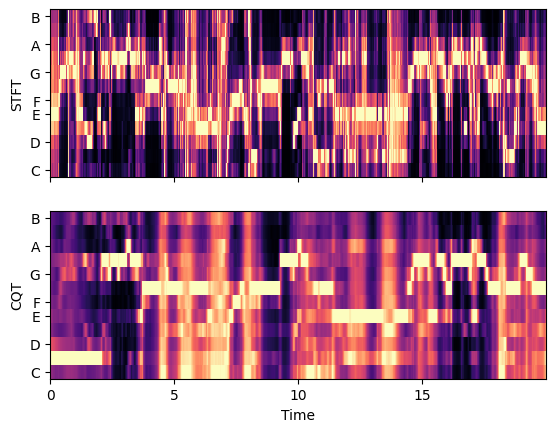

In [3]:
# For display purposes, let's zoom in on a 20-second chunk from the middle of the song
idx = tuple([slice(None), slice(*list(librosa.time_to_frames([40, 60])))])

#using only the harmonic
chroma_stft = librosa.feature.chroma_stft(y=y_harmonic, sr=sampling_rate)
chroma_cqt = librosa.feature.chroma_cqt(y=y_harmonic, sr=sampling_rate)

fig, ax = plt.subplots(nrows=2, sharex=True, sharey=True)
librosa.display.specshow(chroma_stft[idx], y_axis='chroma', x_axis='time', ax=ax[0])
ax[0].set(ylabel='STFT harmonic')
ax[0].label_outer()

librosa.display.specshow(chroma_cqt[idx], y_axis='chroma', x_axis='time', ax=ax[1])
ax[1].set(ylabel='CQT harmonic')


#using the whole "wave"
chroma_stft_2 = librosa.feature.chroma_stft(y=waveform, sr=sampling_rate)
chroma_cqt_2 = librosa.feature.chroma_cqt(y=waveform, sr=sampling_rate)

fig, ax = plt.subplots(nrows=2, sharex=True, sharey=True)
librosa.display.specshow(chroma_stft_2[idx], y_axis='chroma', x_axis='time', ax=ax[0])
ax[0].set(ylabel='STFT')
ax[0].label_outer()

librosa.display.specshow(chroma_cqt_2[idx], y_axis='chroma', x_axis='time', ax=ax[1])
ax[1].set(ylabel='CQT')

***Create_chroma method***  
We start by calculating the time we want between the chroma frames -> hop_length 
It can be compared to taking a screenshot while watching a film. One screenshot is one chroma sample.  
hop_length is how often you want to take the screenshot.
  
This can be made static. There is many examples where it is always set to 2048 or 4096. 

Here we are using the samling_rate which is how many samples there is per second for this recording.




In [4]:
#def create_chroma(y_harmonic, y_percussive, sampling_rate, jump_time):
jump_time = 0.05
y_harmonic, y_percussive = librosa.effects.hpss(waveform)   
hop_length = int(sampling_rate * jump_time)

Next, we are creating the initial chroma by using y_harmonic, the sample rate and the hop_length. We did earlier split up the soundwave into two waves.
-  y_harmonic, that focuses on the harmonic parts of the audio -> good for chords
- y_percussive, that focuses on the drums and the beats of the audio -> good for beats
  

This will give us a numpy array with the shape (12, N)  
12 rows with the pitch classes and T time frames for every jump that shows how active this pitch class is at that moment.

Librosa chroma pitch class comes in this order:  
[C, C#, D, D#, E, F, F#, G, G#, A, A#, B]  

In [5]:
 #create the chroma by using the harmonic wave
the_chroma = librosa.feature.chroma_cqt(
    y=y_harmonic,
    sr=sampling_rate,
    hop_length=hop_length
)

Next we are computing the tempo and the beat frames. The tempo is actually not needed but this method will give us that anyway. What we do need is the beat frames. 
The beat_frames will give you an list of integers, which are the indexes of the frames in the initial chroma where the method thinks that the beat is.

For this we are using the y_harmonic (good for beats) and the same hop_length and sample rate as before.

In [6]:
#get the tempo and an array of all the frame indices where there is a beat

tempo, index_of_the_beats = librosa.beat.beat_track(
    y=y_percussive, 
    sr=sampling_rate,
    hop_length=hop_length
)

In this step we are turning time-synchronous chroma into beat-synchronous chroma to match the McGill dataset.  
We use the initial chromagram, and cut it in the indices where there is a beat. For every interval we calculate the median for each pitch class. That gives us a new chroma where we have a median "screenshot" of the actual chord for each beat. 

In [7]:
#put together the beat with the frames so that you 
#have a list of the frames that is within two beats.
beat_chroma = librosa.util.sync(
    the_chroma,
    index_of_the_beats,
    aggregate=np.median,
    pad=False
)

So far we have only been using frame indices, but in the McGill dataset time is used to track when pitch classes are active.
When using librosas frames_to_time method we will get a time marker for when each beat occurs in the song.  
This will give us a vector of timestamps that correlates to where each beat occur in the songs timeline.

In [8]:
beat_into_time = librosa.frames_to_time(
    index_of_the_beats,
    sr=sampling_rate,
    hop_length=hop_length
)

Until now, the columns represented the timeline of the song. The shape of the chroma is (12, N). To match the McGill dataset we need to transpose the array (Like we did in the labs).  
  
After transposing, the shape becomes (N,12)  
- each row = the median "screen shot" of one beat interval  
- each column = one pitch class

In [9]:
beat_chroma_T = beat_chroma.T


print("beat_into_time: ",beat_into_time.shape)
print("beat_chroma_T: ",beat_chroma_T.shape)

beat_into_time:  (276,)
beat_chroma_T:  (275, 12)


Now we have a chromagram with the 12 pich classes and ve have a vector with the timestamps. What is left is to put them together. But take a look at the printing above. Do you see a problem?  
  
The shapes are not matching. How did that happen?  
Lets say that you have the frames: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10] 

Librosa is telling us that we have the beats at [3, 6, 9]  
  
Then the intevals are: 0->2, 3->5, 6->8, 9->10  
That is 3 beats, but 4 intervals.  

Removing the padding in the method removes the interval added in the start and the end and still give non matching numbers.

To add the timestamps to the chroma, we have to make them the same size.

To fix this we slice and take all beats except for the first one ( [:-1] ) and all the beats except the last one ( [1:] ).
Add them together to get pairs of neighboring beats. Multiply it with 0.5 to get the time halfway between the beats.

In [12]:
sliced_beat_into_times = 0.5 * (beat_into_time[:-1] + beat_into_time[1:])


print("beat_into_time: ",beat_into_time.shape)
print("beat_into_time updated: ",sliced_beat_into_times.shape)
print("beat_chroma_T: ",beat_chroma_T.shape)
        



beat_into_time:  (276,)
beat_into_time updated:  (275,)
beat_chroma_T:  (275, 12)


Now just put it together

In [ ]:
chroma = np.column_stack((sliced_beat_into_times, beat_chroma_T))

print("Chroma shape: ", chroma.shape )

Chroma shape:  (275, 13)
